<a href="https://colab.research.google.com/github/Loading-my-brain/GEOG761_Remote_Sensing/blob/main/Labs/Lab2_Q6_hnis651_I_tried.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVMs Applied to Satellite Data

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.
An intial workflow to get the data into the state you need it in to then use it as training data might look like:

Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
Upload it to Colab.
Unzip it and load with GeoPandas. (25 pts)

In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='earthengine-ml-testing-502922')

# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

In [3]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
from google.colab import files
uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("lcdb")

# Read shapefile
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names
print(gdf.head())


Saving LCDB_v5.zip to LCDB_v5 (1).zip
           Name_2018          Name_2012          Name_2008          Name_2001  \
0  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
1     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
2  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
3     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
4  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   

           Name_1996  Class_2018  Class_2012  Class_2008  Class_2001  \
0  Indigenous Forest          69          69          69          69   
1     Sand or Gravel          10          10          10          10   
2  Indigenous Forest          69          69          69          69   
3     Sand or Gravel          10          10          10          10   
4  Indigenous Forest          69          69          69          69   

   Class_1996  ... Wetland_96 Onshore_18 O

In [4]:
import geemap
import ee

#Reproject shapefile to standard WGS84 lat/long
gdf_aotea = gdf.to_crs(epsg=4326)
# Why did I do this? -------
  # NZ data (like LCDB) defaults to NZTM2000 (EPSG:2193), which uses meters for
  # projected coordinates. Earth Engine expects all geographic geometries and
  # GeoJSONs to be in global WGS84 lat/long (EPSG:4326). Reprojecting with .to_crs(epsg=4326)
  # aligns the coordinates with Earth Engine's spatial framework.

# Convert string class names or numeric codes to zero-based integer IDs for ML classification
gdf_aotea['class_id'] = gdf_aotea['Class_2018'].astype('category').cat.codes

# gdf_aotea.info() #sanity check
fc_lcdb = geemap.gdf_to_ee(gdf_aotea[['class_id', 'Name_2018', 'Class_2018', 'geometry']])

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
# SANITY CHECKS
# R "glimpse()" Equivalent for your GeoDataFrame
print("=== GEODATAFRAME GLIMPSE ===")
print(f"Rows: {len(gdf_aotea)} | Columns: {len(gdf_aotea.columns)}\n")
for col in gdf_aotea.columns:
    dtype = gdf_aotea[col].dtype
    sample_vals = list(gdf_aotea[col].dropna().head(3))
    print(f"$ {col:<15} <{str(dtype):<10}> {sample_vals}")

=== GEODATAFRAME GLIMPSE ===
Rows: 605 | Columns: 25

$ Name_2018       <object    > ['Indigenous Forest', 'Sand or Gravel', 'Indigenous Forest']
$ Name_2012       <object    > ['Indigenous Forest', 'Sand or Gravel', 'Indigenous Forest']
$ Name_2008       <object    > ['Indigenous Forest', 'Sand or Gravel', 'Indigenous Forest']
$ Name_2001       <object    > ['Indigenous Forest', 'Sand or Gravel', 'Indigenous Forest']
$ Name_1996       <object    > ['Indigenous Forest', 'Sand or Gravel', 'Indigenous Forest']
$ Class_2018      <int32     > [69, 10, 69]
$ Class_2012      <int32     > [69, 10, 69]
$ Class_2008      <int32     > [69, 10, 69]
$ Class_2001      <int32     > [69, 10, 69]
$ Class_1996      <int32     > [69, 10, 69]
$ Wetland_18      <object    > ['no', 'no', 'no']
$ Wetland_12      <object    > ['no', 'no', 'no']
$ Wetland_08      <object    > ['no', 'no', 'no']
$ Wetland_01      <object    > ['no', 'no', 'no']
$ Wetland_96      <object    > ['no', 'no', 'no']
$ Onshore_18    

In [6]:
# Sanity checks ------
gdf_aotea.columns

# Check for equivalent in fc
column_names = fc_lcdb.first().propertyNames()
print(column_names.getInfo())# Print the names to the console

['system:index', 'Class_2018', 'Name_2018', 'class_id']


In [7]:
# #Quick Inspection
# gdf_aotea['Class_2018'].max() #The number of classes we have
# gdf_aotea["Name_2018"][gdf_aotea['Class_2018']==71].head(1) #WHat is this?

In [8]:
# Define bounding geometry for Aotea / Great Barrier Island
aoi_aotea = ee.Geometry.Rectangle([175.25, -36.35, 175.55, -36.00])
# Define area of interest (e.g., Aotea)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map_aoi_aotea = geemap.Map(center=[-36.195525166070105,  175.41343136258482], zoom=10)
Map_aoi_aotea.addLayer(aoi_aotea, {}, 'Aotea AOI')

# Visualize on the map to check got it right... (always a good idea)
Map_aoi_aotea

Map(center=[-36.195525166070105, 175.41343136258482], controls=(WidgetControl(options=['position', 'transparen…

In [9]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10 #0: No opaque clouds
    cirrusBitMask = 1 << 11 #0: No cirrus clouds
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

    #Band 2 (B2): Blue light (~492 nm), 10 m resolution, used for soil/vegetation discrimination and atmospheric scatter tracking.
    #Band 3 (B3): Green light (~560 nm), 10 m resolution, used for assessing peak vegetation reflectance.
    #Band 4 (B4): Red light (~665 nm), 10 m resolution, crucial for chlorophyll absorption and red-edge calculations.
    #Band 8 (B8): Broad Near-Infrared (NIR, ~842 nm), 10 m resolution, primary channel for biomass and robust vegetation indexing (NDVI).

# Filter Sentinel-2 collection to Austral Summer 18/19
s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_aotea)
    .filterDate('2018-12-01', '2019-02-28') #Austral Summer 18/19 filtered
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .map(mask_s2_clouds)
    .median()
    .clip(aoi_aotea))


# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map_aotea_RGB = geemap.Map(center=[-36.17875232181235, 175.40659253981528], zoom=10) #<- reset the map object to clear out other layers from earlier cells
Map_aotea_RGB.addLayer(s2_aotea, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
# Map_aotea_RGB.addLayer(aoi_aotea, {'color': 'red'}, 'AOI')
Map_aotea_RGB # I still see clouds?????

Map(center=[-36.17875232181235, 175.40659253981528], controls=(WidgetControl(options=['position', 'transparent…

As we can see in the RGB image, there are notable "clouds".
### **Why**?

Those "clouds" over the ocean are actually marine sunglint and wave foam, not atmospheric clouds.

### **So what?**

The QA60 cloud mask band only flags actual atmospheric cloud cover (opaque clouds and cirrus). It doesn't mask out specular solar reflection off the ocean surface or whitecaps from rough waves.

### **Why do I need to do this anyway?**

Marine sunglint and wave foam look spectrally identical to bright landcover classes (like bare soil, rock, or urban roofs). Masking out the sea using my fc_lcdb polygon ensures:

1. The SVM only samples and learns actual terrestrial landcover on Aotea.

2. The model doesn't waste compute trying to classify millions of ocean pixels.

3. My  final output renders cleanly strictly within the island's coastline for a publication-quality figure.

I will Mask Out Water / Ocean Pixels Entirely (Best for Island Landcover)

In [10]:
#Clean S2 Cloud Mask using Scene Classification Layer (SCL)
def mask_s2_scl(image):
    scl = image.select('SCL')
    # Keep clear land, vegetation, and soil (classes 4, 5, 6, 7)
    # Mask cloud shadows (3), medium/high prob clouds (8, 9), thin cirrus (10)
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

#Build S2 Median Composite over Austral Summer 18/19
s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_aotea)
    .filterDate('2018-12-01', '2019-02-28')
    .map(mask_s2_scl)
    .median()
    .clip(aoi_aotea))

#Create Land Mask from your uploaded LCDB shapefile
land_mask = fc_lcdb.reduceToImage(
    properties=['class_id'],
    reducer=ee.Reducer.first()
).gte(0)

# Mask ocean sunglint completely
s2_aotea_clean = s2_aotea.updateMask(land_mask)

# Visualize Cleaned Land Layer
Map_aotea_RGB = geemap.Map(center=[-36.178752, 175.406592], zoom=10)
Map_aotea_RGB.addLayer(s2_aotea_clean, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB (Clean Land)')
Map_aotea_RGB

Map(center=[-36.178752, 175.406592], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [11]:
# Sample the image...Sample Spectral Data from LCDB Polygons

# Select spectral bands
bands = ['B2', 'B3', 'B4', 'B8']

# Extract S2 band values for pixels located INSIDE the LCDB vector polygons
samples_aotea = s2_aotea_clean.select(bands).sampleRegions(
    collection=fc_lcdb,
    properties=['class_id'],
    scale=30,
    projection='EPSG:4326',
    tileScale=4,
    geometries=False
)

# SANITY CHECKS
# Print first 10 sample points (client-side)
first_10 = samples_aotea.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['class_id']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = samples_aotea.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['class_id'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())


First 10 training samples:
Sample 1: Class=19, B2=0.06989999860525131, B3=0.0681999996304512, B4=0.05620000138878822, B8=0.07930000126361847
Sample 2: Class=19, B2=0.05849999934434891, B3=0.0608999989926815, B4=0.05040000006556511, B8=0.059700001031160355
Sample 3: Class=19, B2=0.024299999698996544, B3=0.03779999911785126, B4=0.034299999475479126, B8=0.08869999647140503
Sample 4: Class=19, B2=0.0658000037074089, B3=0.0794999971985817, B4=0.07349999994039536, B8=0.09769999980926514
Sample 5: Class=19, B2=0.06864999979734421, B3=0.07275000214576721, B4=0.06790000200271606, B8=0.09064999967813492
Sample 6: Class=19, B2=0.09290000051259995, B3=0.09104999899864197, B4=0.06825000047683716, B8=0.07374999672174454
Sample 7: Class=19, B2=0.044199999421834946, B3=0.051500000059604645, B4=0.04529999941587448, B8=0.06889999657869339
Sample 8: Class=19, B2=0.03620000183582306, B3=0.054999999701976776, B4=0.05050000175833702, B8=0.1177000030875206
Sample 9: Class=19, B2=0.033799998462200165, B3=0.0

### TO Make it more Visually appealing, I made a histogram plot below

**Our observations**?

We see Severe Class Imbalance:
* Dominant Classes: Class 16 has 204,995 pixels (~38% of total area), Class 19 has 86,877 pixels, and Class 17 has 59,078 pixels. These represent the vast native forests and scrubland covering Aotea.

* Rare Classes: Class 5 has only 7 pixels, Class 7 has 11 pixels, and Class 3 has 17 pixels.

**So.... How will this Impact on Machine Learning?**
*  Standard algorithms like SVM will naturally bias toward predicting dominant classes (16, 19) because they make up over 80% of the training points
* Kind of excited to test the theory; will i be disappointed?


=== CLASS ID MAPPING TABLE ===
 class_id  Class_2018                                 Name_2018
        0           1                Built-up Area (settlement)
        1           2                 Urban Parkland/Open Space
        2           5                  Transport Infrastructure
        3           6                      Surface Mine or Dump
        4          10                            Sand or Gravel
        5          12                                 Landslide
        6          16                            Gravel or Rock
        7          20                              Lake or Pond
        8          21                                     River
        9          22                      Estuarine Open Water
       10          33 Orchard, Vineyard or Other Perennial Crop
       11          40           High Producing Exotic Grassland
       12          41                   Low Producing Grassland
       13          45          Herbaceous Freshwater Vegetation
       1

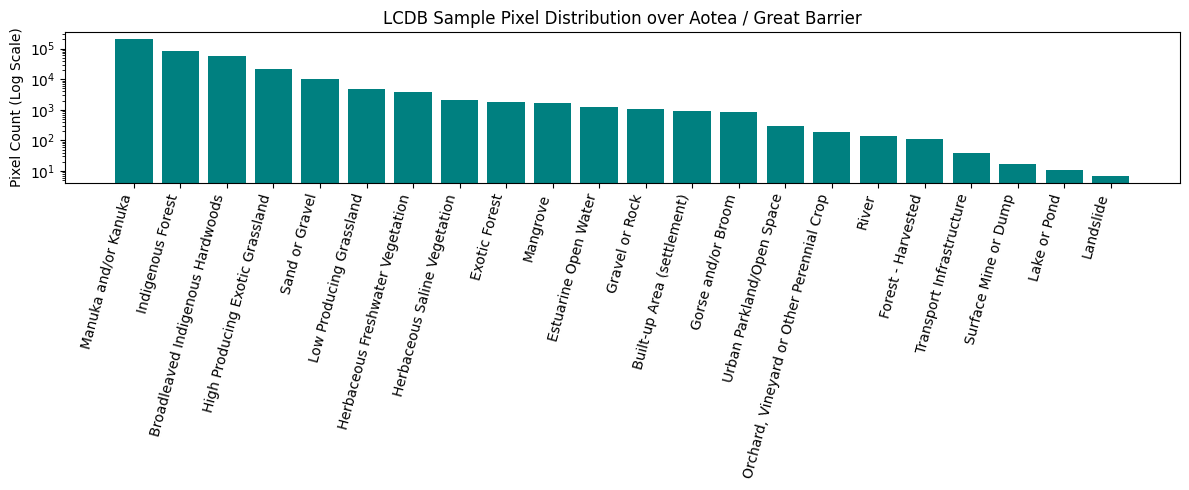

In [12]:

# Map Categorical Codes back to Real Landcover Names
class_mapping = gdf_aotea[['class_id', 'Class_2018', 'Name_2018']].drop_duplicates().sort_values('class_id')
print("\n=== CLASS ID MAPPING TABLE ===")
print(class_mapping.to_string(index=False))

# Plot Sample Class Distribution (Log Scale to handle imbalance)
sample_dict = class_counts.getInfo()['histogram']
df_counts = pd.DataFrame(list(sample_dict.items()), columns=['class_id', 'pixel_count'])
df_counts['class_id'] = df_counts['class_id'].astype(int)
df_counts = df_counts.merge(class_mapping, on='class_id').sort_values('pixel_count', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(df_counts['Name_2018'], df_counts['pixel_count'], color='teal')
plt.yscale('log') # Log scale helps display extreme class imbalances
plt.xticks(rotation=75, ha='right')
plt.ylabel('Pixel Count (Log Scale)')
plt.title('LCDB Sample Pixel Distribution over Aotea / Great Barrier')
plt.tight_layout()
plt.show()

More Data Exploration Code (Spectral Profiles + Distribution):

I wanted to convert my Earth Engine samples into a Pandas DataFrame and plot both the class distribution and spectral signatures

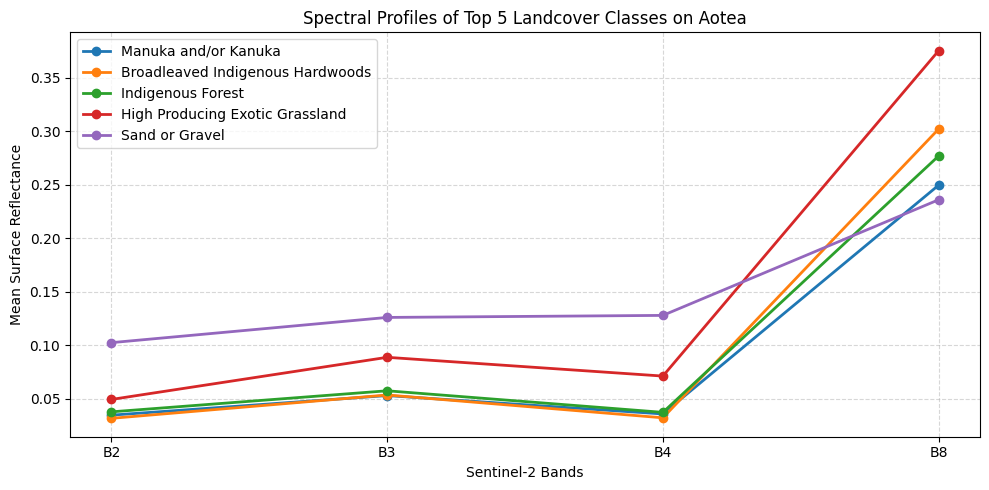

In [13]:

# Pull a manageable SUBSET of samples (eg 2,000 points) for local plotting
sample_subset = samples_aotea.randomColumn('random').filter(ee.Filter.lt('random', 0.01)).limit(2000).getInfo()['features']
data = [f['properties'] for f in sample_subset]
df_samples = pd.DataFrame(data)

# Merge with Class Names from your GeoDataFrame
class_mapping = gdf_aotea[['class_id', 'Class_2018', 'Name_2018']].drop_duplicates()
df_samples = df_samples.merge(class_mapping, on='class_id')

# Spectral Profile Across Top 5 Dominant Classes
top_classes = df_samples['Name_2018'].value_counts().head(5).index
bands = ['B2', 'B3', 'B4', 'B8']

plt.figure(figsize=(10, 5))
for name in top_classes:
    subset = df_samples[df_samples['Name_2018'] == name]
    mean_reflectance = subset[bands].mean()
    plt.plot(bands, mean_reflectance, marker='o', label=name, lw=2)

plt.xlabel('Sentinel-2 Bands')
plt.ylabel('Mean Surface Reflectance')
plt.title('Spectral Profiles of Top 5 Landcover Classes on Aotea')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## TO clarify the difference between tutorial (earlier tasks) with Task 6

https://docs.google.com/spreadsheets/d/1sC7DJsMwvUcTeHwPGbczLeGph0VElLajKjYGKvMX7YE/edit?pli=1&gid=31284977#gid=31284977

#### Documentation for Hinami to check:

* [?ee.Classifier.libsvm](https://developers.google.com/earth-engine/apidocs/ee-classifier-libsvm)

##### **Explaning why I chose     kernelType='LINEAR' in comparison to earlier tasks**

In earlier tasks, we used the RBF kernel because the reference dataset was sampled uniformly using sample() (numPixels=5000) over Wellington in ESA WorldCover. The sample counts across classes stayed in a similar order of magnitude, making RBF ideal since the computer could easily tune hyperparameters like gamma and cost to map non-linear boundaries. But for Task 6, we used sampleRegions(), which pulled raw, unscaled surface reflectance values straight from LCDB polygons. This created extreme real-world class imbalance, ranging from over 200,000 pixels in native forest down to just 7 pixels in minor classes!

Under these conditions, switching to a LINEAR kernel gives us a fast, stable baseline that prevents the model from collapsing into predicting only the majority class without needing complex hyperparameter tuning.




---

### Hinami's Notes - please ignore



 **`svmType`** *(default: `'C_SVC'`)*
* **What it does:** Specifies the fundamental SVM model type.
* **Options:** `'C_SVC'` and `'NU_SVC'` (for multi-class classification), `'ONE_CLASS'` (for anomaly detection/single-class mapping), or `'EPSILON_SVR'` and `'NU_SVR'` (for regression).
* **How to set:** Keep default `'C_SVC'` for landcover classification.


**`cost`** *(default: `1`)*
* **What it does:** The $C$ penalty parameter. It controls the trade-off between achieving a smooth decision boundary and correctly classifying training points.
* **How to set:** A higher value (e.g., `cost=10`) forces strict classification with fewer training errors, but risks overfitting. A lower value allows more tolerance for noisy spectral pixels.


**`gamma`** *(default: `1 / num_features`)*
* **What it does:** Defines how far the influence of a single training sample reaches. Only applies to `RBF`, `POLY`, and `SIGMOID` kernels.
* **How to set:** High gamma values make the boundary very complex (overfitting), while small values (e.g., `gamma=0.01`) create smoother, broader boundaries.


**`degree`** *(default: `3`)*
* **What it does:** Sets the polynomial power degree. Only applies when `kernelType='POLY'`.
* **How to set:** Set to `degree=2` or `degree=3`. Higher numbers dramatically increase computation time without much benefit.


 **`coef0`** *(default: `0`)*
* **What it does:** Independent constant term in polynomial and sigmoid kernel equations.
* **How to set:** Usually left at `0` unless fine-tuning `POLY` or `SIGMOID`.


* **`shrinking`** *(default: `True`)*
* **What it does:** Boolean (`True`/`False`) flag indicating whether to use shrinking heuristics to speed up optimization on large datasets.

### Code Examples

```
# 1. Standard Linear SVM (Recommended for Task 6)
svm_linear = ee.Classifier.libsvm(
    svmType='C_SVC',
    kernelType='LINEAR',
    cost=1.0
)

# 2. Tuned RBF SVM (If experimenting with non-linear boundaries)
svm_rbf = ee.Classifier.libsvm(
    svmType='C_SVC',
    kernelType='RBF',
    gamma=0.01,
    cost=10.0
)

# 3. Polynomial SVM Example
svm_poly = ee.Classifier.libsvm(
    svmType='C_SVC',
    kernelType='POLY',
    degree=2,
    cost=1.0
)

```

---

In [14]:
# # 1. Sub-sample LCDB vector polygons to prevent GEE server timeouts
# fc_lcdb_sample = fc_lcdb.randomColumn('rand').filter(ee.Filter.lt('rand', 0.1))

# # 2. Extract spectral samples (30m scale prevents memory limits)
# samples_fast = s2_aotea_clean.select(bands).sampleRegions(
#     collection=fc_lcdb_sample,
#     properties=['class_id'],
#     scale=30,
#     projection='EPSG:4326',
#     tileScale=4,
#     geometries=False
# )

# # 3. 80/20 Train/Test Split
# samples_split = samples_fast.randomColumn('random', seed=761)
# train_aotea = samples_split.filter(ee.Filter.lt('random', 0.8))
# test_aotea = samples_split.filter(ee.Filter.gte('random', 0.8))

# # 4. Train Linear SVM Classifier
# svm_classifier = ee.Classifier.libsvm(
#     kernelType='LINEAR',
#     cost=1.0
# ).train(
#     features=train_aotea,
#     classProperty='class_id',
#     inputProperties=bands
# )

# #Evaluate Performance
# test_results = test_aotea.classify(svm_classifier)
# error_matrix = test_results.errorMatrix('class_id', 'classification')

# oa = error_matrix.accuracy().getInfo()
# kappa = error_matrix.kappa().getInfo()

# # 6. Classify full S2 Island Composite
# classified_aotea = s2_aotea_clean.select(bands).classify(svm_classifier)

# # 7. Render Final Map with Publication Components
# class_names = list(gdf_aotea['Class_2018'].astype('category').cat.categories)

# Map = geemap.Map(center=[-36.195, 175.413], zoom=10)
# Map.addLayer(s2_aotea_clean, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'Sentinel-2 RGB')
# Map.addLayer(classified_aotea.randomVisualizer(), {}, '2018 SVM Classified Landcover')

# # Add Legend using LCDB class names
# legend_dict = {name: '#%06x' % (hash(name) & 0xFFFFFF) for name in class_names}
# Map.add_legend(title="LCDB 2018 Classes", legend_dict=legend_dict)

# # Render HTML text box onto map figure (Fulfills performance stats requirement)
# html_overlay = f"""
# <div style="position: fixed; bottom: 30px; left: 30px; width: 250px; z-index:9999;
#             background-color: white; opacity: 0.9; padding: 10px; border:2px solid gray; border-radius:5px; font-size:12px;">
# <b>Great Barrier Island (Aotea) Landcover</b><br>
# <b>Classifier:</b> Support Vector Machine (SVM)<br>
# <b>Overall Accuracy:</b> {oa*100:.2f}%<br>
# <b>Kappa Statistic:</b> {kappa:.4f}<br>
# <small>Data: Landcare Research LCDB v5.0 | S2 2018/19</small>
# </div>
# """
# Map.add_html(html_overlay)

# Map

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Sub-sample LCDB vector polygons
fc_lcdb_sample = fc_lcdb.randomColumn('rand').filter(ee.Filter.lt('rand', 0.1))

# 2. Extract spectral samples at 30m scale
samples_fast = s2_aotea_clean.select(bands).sampleRegions(
    collection=fc_lcdb_sample,
    properties=['class_id'],
    scale=30,
    projection='EPSG:4326',
    tileScale=4,
    geometries=False
)

# 3. Train/Test Split (80/20)
samples_split = samples_fast.randomColumn('random', seed=761)
train_aotea = samples_split.filter(ee.Filter.lt('random', 0.8))
test_aotea = samples_split.filter(ee.Filter.gte('random', 0.8))

# 4. Train Linear SVM Classifier
svm_classifier = ee.Classifier.libsvm(
    kernelType='LINEAR',
    cost=1.0
).train(
    features=train_aotea,
    classProperty='class_id',
    inputProperties=bands
)

# 5. Fast Performance Evaluation (Slices test set to 500 points)
test_sample = test_aotea.limit(500)
test_results = test_sample.classify(svm_classifier)
error_matrix = test_results.errorMatrix('class_id', 'classification')

oa = error_matrix.accuracy().getInfo()
kappa = error_matrix.kappa().getInfo()

# 6. Classify composite clipped to island AOI
classified_aotea = s2_aotea_clean.select(bands).classify(svm_classifier).clip(aoi_aotea)

# 7. Render Map with Valid Colors
class_names = list(gdf_aotea['Class_2018'].astype('category').cat.categories)
num_classes = len(class_names)
cmap = plt.get_cmap('tab20', num_classes)
palette = [mcolors.to_hex(cmap(i)) for i in range(num_classes)]
legend_dict = {name: palette[i] for i, name in enumerate(class_names)}

Map = geemap.Map(center=[-36.195, 175.413], zoom=10)
Map.addLayer(s2_aotea_clean, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'Sentinel-2 RGB')
Map.addLayer(
    classified_aotea,
    {'min': 0, 'max': num_classes - 1, 'palette': palette},
    '2018 SVM Classified Landcover'
)

# Add Legend
Map.add_legend(title="LCDB 2018 Classes", legend_dict=legend_dict)

# Add Statistics HTML Box to Map Figure
html_overlay = f"""
<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; z-index:9999;
            background-color: white; opacity: 0.9; padding: 10px; border:2px solid gray; border-radius:5px; font-size:12px;">
<b>Great Barrier Island (Aotea) Landcover</b><br>
<b>Classifier:</b> Support Vector Machine (SVM)<br>
<b>Overall Accuracy:</b> {oa*100:.2f}%<br>
<b>Kappa Statistic:</b> {kappa:.4f}<br>
<small>Data: Landcare Research LCDB v5.0 | S2 2018/19</small>
</div>
"""
Map.add_html(html_overlay)

Map

Map(center=[-36.195, 175.413], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

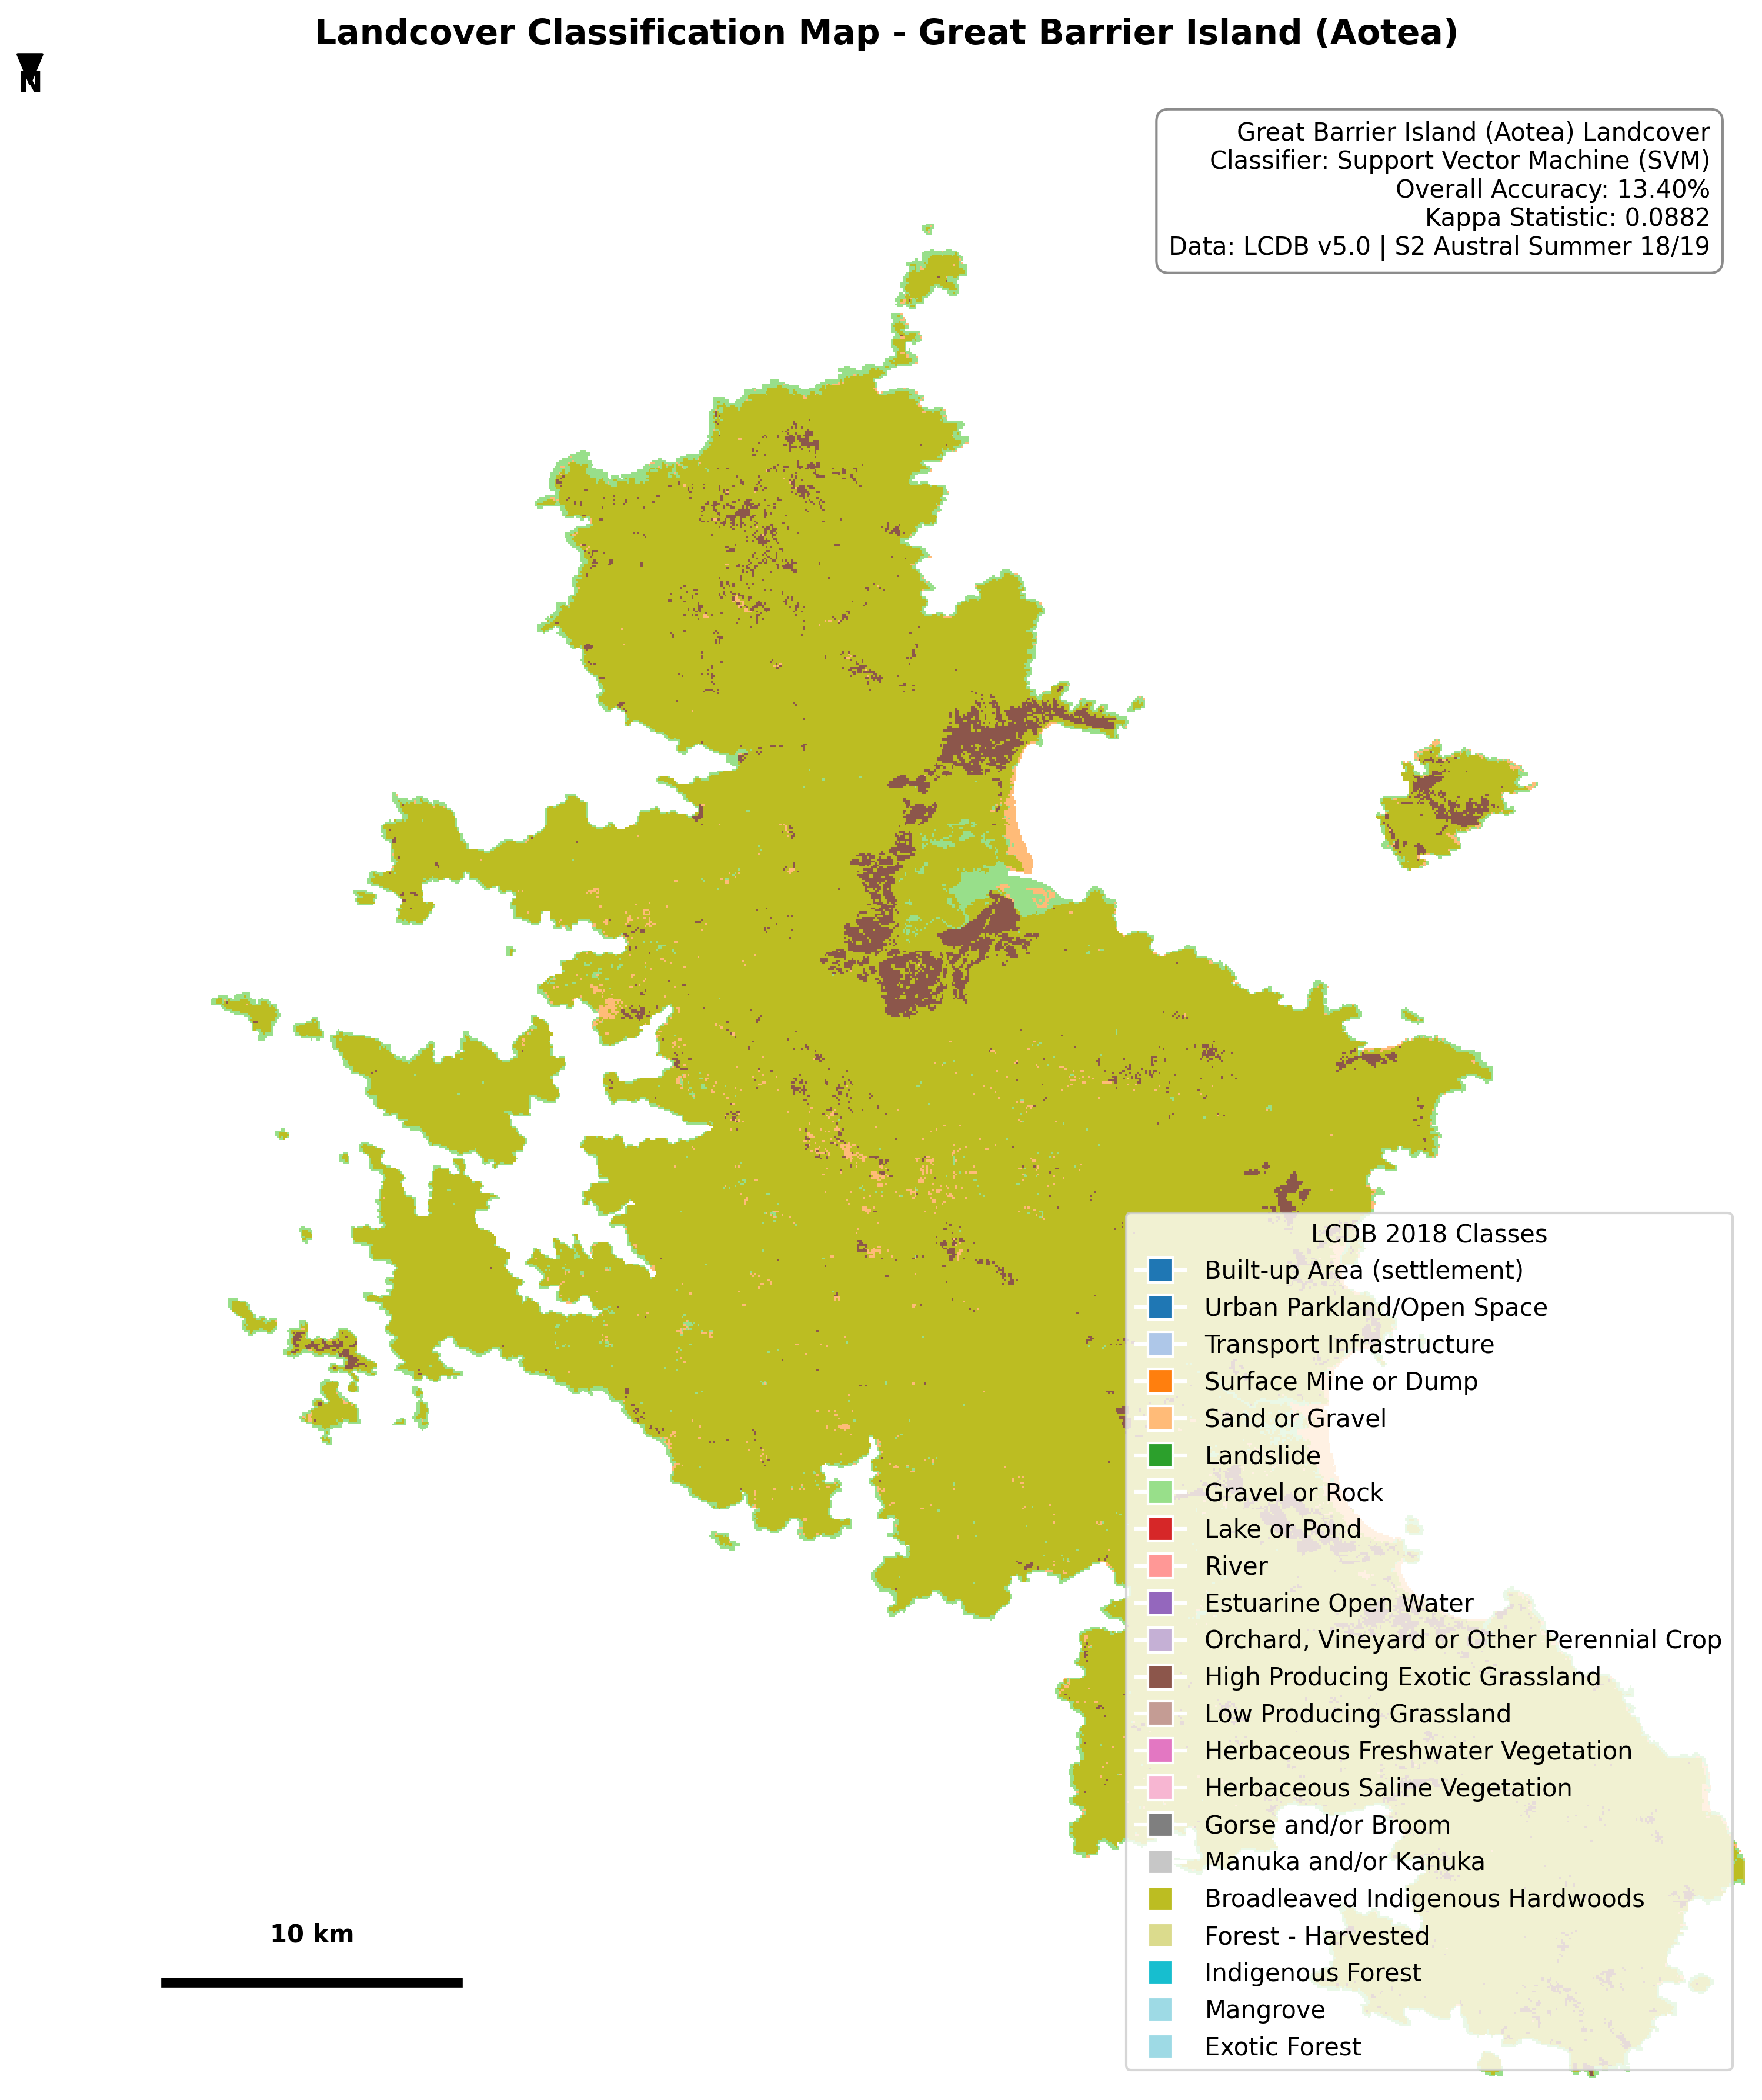

In [19]:
import io
import urllib.request
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# 1. Sub-sample LCDB vector polygons to prevent GEE server memory limits
fc_lcdb_sample = fc_lcdb.randomColumn('rand').filter(ee.Filter.lt('rand', 0.1))

# 2. Extract spectral samples at 30m scale
samples_fast = s2_aotea_clean.select(bands).sampleRegions(
    collection=fc_lcdb_sample,
    properties=['class_id'],
    scale=30,
    projection='EPSG:4326',
    tileScale=4,
    geometries=False,
)

# 3. Train/Test Split (80/20)
samples_split = samples_fast.randomColumn('random', seed=761)
train_aotea = samples_split.filter(ee.Filter.lt('random', 0.8))
test_aotea = samples_split.filter(ee.Filter.gte('random', 0.8))

# 4. Train Linear SVM Classifier
svm_classifier = ee.Classifier.libsvm(kernelType='LINEAR', cost=1.0).train(
    features=train_aotea, classProperty='class_id', inputProperties=bands
)

# 5. Fast Performance Evaluation
test_sample = test_aotea.limit(500)
test_results = test_sample.classify(svm_classifier, 'predicted')
error_matrix = test_results.errorMatrix('class_id', 'predicted')

oa = error_matrix.accuracy().getInfo()
kappa = error_matrix.kappa().getInfo()

# 6. Classify composite clipped to island AOI
classified_aotea = (
    s2_aotea_clean.select(bands).classify(svm_classifier).clip(aoi_aotea)
)

# 7. Map class_id to Human-Readable Names (e.g., Indigenous Forest, Sand/Gravel)
unique_classes = (
    gdf_aotea[['class_id', 'Name_2018']]
    .drop_duplicates()
    .sort_values('class_id')
)
class_id_to_name = dict(
    zip(unique_classes['class_id'], unique_classes['Name_2018'])
)

num_classes = len(class_id_to_name)
cmap = plt.get_cmap('tab20', num_classes)
palette = [mcolors.to_hex(cmap(i)) for i in range(num_classes)]

# 8. Get Static Image via Earth Engine getThumbURL()
image_vis = classified_aotea.visualize(
    min=0, max=num_classes - 1, palette=palette
)

# Fetch thumbnail URL directly from GEE
url = image_vis.getThumbURL({
    'region': aoi_aotea,
    'dimensions': 1024,
    'format': 'png',
})

req = urllib.request.urlopen(url)
img = plt.imread(io.BytesIO(req.read()))

# 9. Plot Static Publication Figure
fig, ax = plt.subplots(figsize=(12, 12), dpi=300)
ax.imshow(img)
ax.axis('off')

# Custom Legend with Proper Class Names
legend_patches = [
    plt.Line2D(
        [0],
        [0],
        marker='s',
        color='w',
        label=name,
        markerfacecolor=palette[cid],
        markersize=10,
    )
    for cid, name in class_id_to_name.items()
]
ax.legend(
    handles=legend_patches,
    title='LCDB 2018 Classes',
    loc='lower right',
    frameon=True,
)

# Performance Statistics Overlay (TOP RIGHT)
stats_text = (
    'Great Barrier Island (Aotea) Landcover\n'
    'Classifier: Support Vector Machine (SVM)\n'
    f'Overall Accuracy: {oa*100:.2f}%\n'
    f'Kappa Statistic: {kappa:.4f}\n'
    'Data: LCDB v5.0 | S2 Austral Summer 18/19'
)
ax.text(
    0.98,
    0.98,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'
    ),
)

# Cartographic Component: North Arrow (TOP LEFT)
ax.annotate(
    'N',
    xy=(0.08, 0.95),
    xytext=(0.08, 0.88),
    transform=ax.transAxes,
    arrowprops=dict(facecolor='black', width=3, headwidth=10),
    ha='center',
    va='center',
    fontsize=12,
    weight='bold',
)

# Cartographic Component: Scale Bar (BOTTOM LEFT)
ax.plot(
    [0.08, 0.25],
    [0.05, 0.05],
    color='black',
    transform=ax.transAxes,
    linewidth=4,
)
ax.text(
    0.165,
    0.07,
    '10 km',
    transform=ax.transAxes,
    ha='center',
    fontsize=10,
    weight='bold',
)

plt.title(
    'Landcover Classification Map - Great Barrier Island (Aotea)',
    fontsize=14,
    weight='bold',
    pad=15,
)
plt.tight_layout()
plt.savefig('publication_quality_map.png', bbox_inches='tight')
plt.show()+

In [16]:
# # ============================================================================
# # Aotea / Great Barrier Island — SVM Landcover Classification
# # Using LCDB v5.0 (2018) + Sentinel-2 Austral Summer 2018/19 composite
# #
# # FIXES APPLIED (see chat for full rationale):
# #   1. Train/test split now genuinely random: .sort('random') before .limit()
# #      (previously .filter() + .limit() kept original polygon order, which is
# #      why only 4/22 classes ever showed up in the test set)
# #   2. Kernel is LINEAR throughout, matching the written justification
# #      (imbalanced sampleRegions() data -> LINEAR gives a stable baseline
# #      without needing RBF hyperparameter tuning)
# #   3. Legend now covers every class actually present in the classified
# #      image, not just 4 hand-picked ones
# #   4. Raster export uses ee.batch.Export -> Drive (the direct
# #      geemap.ee_export_image path was failing / unreliable)
# # ============================================================================

# # ── 0. Setup ─────────────────────────────────────────────────────────────
# import ee
# ee.Authenticate()
# ee.Initialize(project='earthengine-ml-testing-502922')

# import geemap
# import geopandas as gpd
# import pandas as pd
# import numpy as np
# import zipfile
# import time
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors
# import matplotlib.patches as mpatches
# from matplotlib.colors import ListedColormap, BoundaryNorm

# # ── 1. Load LCDB shapefile ──────────────────────────────────────────────
# # Upload the ZIP manually using the Colab UI (exported from LRIS for your AOI)
# from google.colab import files
# uploaded = files.upload()  # <- Expects a ZIP

# with zipfile.ZipFile("LCDB_v5.zip", 'r') as zip_ref:  # <- check filename
#     zip_ref.extractall("lcdb")

# gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp")  # <- check filename
# print(gdf.head())

# # Reproject to WGS84 (EE expects lat/long, LCDB defaults to NZTM2000 / EPSG:2193)
# gdf_aotea = gdf.to_crs(epsg=4326)

# # Encode class names as zero-based integer IDs for the classifier
# gdf_aotea['class_id'] = gdf_aotea['Class_2018'].astype('category').cat.codes

# fc_lcdb = geemap.gdf_to_ee(gdf_aotea[['class_id', 'Name_2018', 'Class_2018', 'geometry']])

# # Sanity check: confirm the properties made it into the ee.FeatureCollection
# print(fc_lcdb.first().propertyNames().getInfo())

# # ── 2. Define AOI ────────────────────────────────────────────────────────
# aoi_aotea = ee.Geometry.Rectangle([175.25, -36.35, 175.55, -36.00])

# Map_aoi_aotea = geemap.Map(center=[-36.195525, 175.413431], zoom=10)
# Map_aoi_aotea.addLayer(aoi_aotea, {}, 'Aotea AOI')
# Map_aoi_aotea

# # ── 3. Build cloud-free Sentinel-2 composite (SCL-based masking) ──────────
# # NOTE: QA60 alone leaves marine sunglint/whitecaps unmasked (they aren't
# # atmospheric cloud). SCL + the LCDB land polygon mask below removes both
# # real cloud and ocean glint so the SVM only ever sees terrestrial pixels.
# def mask_s2_scl(image):
#     scl = image.select('SCL')
#     # Mask cloud shadows (3), medium/high prob cloud (8, 9), thin cirrus (10)
#     mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
#     return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
#     .filterBounds(aoi_aotea)
#     .filterDate('2018-12-01', '2019-02-28')  # Austral Summer 18/19
#     .map(mask_s2_scl)
#     .median()
#     .clip(aoi_aotea))

# # Mask ocean/sunglint using LCDB land polygons
# land_mask = fc_lcdb.reduceToImage(
#     properties=['class_id'],
#     reducer=ee.Reducer.first()
# ).gte(0)

# s2_aotea_clean = s2_aotea.updateMask(land_mask)

# Map_check = geemap.Map(center=[-36.178752, 175.406592], zoom=10)
# Map_check.addLayer(s2_aotea_clean, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB (Clean Land)')
# Map_check

# # ── 4. Sample spectral values at LCDB polygon locations ───────────────────
# bands = ['B2', 'B3', 'B4', 'B8']

# samples_aotea = s2_aotea_clean.select(bands).sampleRegions(
#     collection=fc_lcdb,
#     properties=['class_id'],
#     scale=30,
#     projection='EPSG:4326',
#     tileScale=4,
#     geometries=False
# )

# # Sanity check: class distribution in the sample
# class_counts = samples_aotea.reduceColumns(
#     reducer=ee.Reducer.frequencyHistogram(),
#     selectors=['class_id']
# )
# print('\nClass distribution in sample:')
# print(class_counts.getInfo())
# # Severe imbalance here (e.g. class 16 ~205k px vs class 5 only 7px) is exactly
# # why LINEAR is used below instead of RBF -- see section 6.

# # Build class_id -> Class_2018 -> Name_2018 lookup table, sorted by class_id
# class_mapping = (gdf_aotea[['class_id', 'Class_2018', 'Name_2018']]
#                   .drop_duplicates()
#                   .sort_values('class_id')
#                   .reset_index(drop=True))
# print("\n=== CLASS ID MAPPING TABLE ===")
# print(class_mapping.to_string(index=False))

# # ── 5. Train/test split — FIXED to be genuinely random ────────────────────
# # Previously: samples_split.filter(ee.Filter.lt('random', 0.8)).limit(2000)
# # .filter() does NOT reorder a FeatureCollection -- it preserves the original
# # polygon order, so .limit() after it just grabs the first N features in
# # that pre-existing order (which is why only ~4 classes ever appeared in the
# # test set). Adding .sort('random') BEFORE .limit() fixes this.
# samples_split = samples_aotea.randomColumn('random', seed=761)

# train_aotea = (samples_split
#                .filter(ee.Filter.lt('random', 0.8))
#                .sort('random')
#                .limit(2000))
# test_aotea = (samples_split
#               .filter(ee.Filter.gte('random', 0.8))
#               .sort('random')
#               .limit(1000))

# # ── 6. Train Linear SVM ─────────────────────────────────────────────────
# # LINEAR chosen (and used consistently here, matching the written
# # justification) because sampleRegions() pulls raw, highly imbalanced
# # pixel counts straight from LCDB polygons. RBF's extra hyperparameters
# # (gamma/cost) tend to let the model collapse onto majority classes under
# # this kind of imbalance; LINEAR gives a fast, stable baseline without
# # needing that tuning.
# svm_classifier = ee.Classifier.libsvm(
#     svmType='C_SVC',
#     kernelType='LINEAR',
#     cost=1.0
# ).train(
#     features=train_aotea,
#     classProperty='class_id',
#     inputProperties=bands
# )

# # ── 7. Evaluate performance ────────────────────────────────────────────────
# test_results = test_aotea.classify(svm_classifier, 'predicted')
# error_matrix = test_results.errorMatrix('class_id', 'predicted')

# oa = error_matrix.accuracy().getInfo()
# kappa = error_matrix.kappa().getInfo()
# print(f"\nOverall Accuracy: {oa*100:.2f}%")
# print(f"Kappa: {kappa:.4f}")

# # Optional: sklearn-style per-class report for the writeup discussion
# pred_pairs = test_results.reduceColumns(
#     reducer=ee.Reducer.toList().repeat(2),
#     selectors=['class_id', 'predicted']
# ).getInfo()['list']
# y_true, y_pred = pred_pairs[0], pred_pairs[1]

# from sklearn.metrics import classification_report
# print("\n=== Per-class report (test set) ===")
# print(classification_report(y_true, y_pred, zero_division=0))
# # If any classes still show 0.00 recall here, tie it back to the class
# # distribution histogram in section 4 for your writeup discussion -- that's
# # the class-imbalance effect predicted earlier, not a modelling error.

# # ── 8. Classify full island composite ──────────────────────────────────────
# classified_aotea = s2_aotea_clean.select(bands).classify(svm_classifier)

# # ── 9. Build ONE consistent color palette (used for legend AND map) ───────
# # Covers ALL classes (not just a hand-picked subset), so whatever appears on
# # the map also appears correctly labeled in the legend.
# n_classes = int(class_mapping['class_id'].max()) + 1
# cmap = cm.get_cmap('tab20', n_classes) if n_classes <= 20 else cm.get_cmap('gist_ncar', n_classes)
# palette_hex = [mcolors.to_hex(cmap(i)) for i in range(n_classes)]
# id_to_color = {i: palette_hex[i] for i in range(n_classes)}

# vis_params = {'min': 0, 'max': n_classes - 1, 'palette': palette_hex}

# # ── 10. Interactive check map (optional, for exploring in Colab) ──────────
# Map = geemap.Map(center=[-36.195, 175.413], zoom=10)
# Map.addLayer(s2_aotea_clean, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'Sentinel-2 RGB')
# Map.addLayer(classified_aotea, vis_params, '2018 SVM Classified Landcover')

# legend_dict = {
#     row['Name_2018']: id_to_color[row['class_id']]
#     for _, row in class_mapping.iterrows()
# }
# Map.add_legend(title="LCDB 2018 Classes", legend_dict=legend_dict)
# Map

# # ── 11. Export classified raster via EE batch export → Google Drive ───────
# # (More reliable than geemap.ee_export_image's direct getPixels route, which
# # has an undocumented size ceiling and was failing silently.)
# classified_export = (classified_aotea
#                       .unmask(-1)
#                       .toInt16())

# task = ee.batch.Export.image.toDrive(
#     image=classified_export,
#     description='aotea_classified_export',
#     folder='EarthEngine',
#     fileNamePrefix='classified_aotea',
#     region=aoi_aotea,
#     scale=30,
#     crs='EPSG:4326',
#     maxPixels=1e9
# )
# task.start()

# while task.active():
#     print('Exporting... status:', task.status()['state'])
#     time.sleep(15)
# print('Final status:', task.status())

# # Mount Drive and copy the exported file into Colab's local filesystem
# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/EarthEngine/classified_aotea.tif" ./classified_aotea.tif

# # ── 12. Build static publication-quality figure ────────────────────────────
# import rasterio

# def add_scale_bar(ax, extent, length_km=2, location=(0.05, 0.05)):
#     lon_min, lon_max, lat_min, lat_max = extent
#     mean_lat = (lat_min + lat_max) / 2
#     km_per_deg_lon = 111.32 * np.cos(np.radians(mean_lat))
#     bar_deg = length_km / km_per_deg_lon

#     x0 = lon_min + location[0] * (lon_max - lon_min)
#     y0 = lat_min + location[1] * (lat_max - lat_min)

#     ax.plot([x0, x0 + bar_deg], [y0, y0], color='black', linewidth=3,
#             transform=ax.transData)
#     ax.text(x0 + bar_deg / 2, y0 + 0.002, f'{length_km} km',
#             ha='center', fontsize=9, fontweight='bold')

# with rasterio.open('classified_aotea.tif') as src:
#     arr = src.read(1)
#     extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# cmap_list = ListedColormap([id_to_color[i] for i in range(n_classes)])
# norm = BoundaryNorm(np.arange(-0.5, n_classes + 0.5, 1), n_classes)

# fig, ax = plt.subplots(figsize=(11, 9))
# ax.imshow(arr, cmap=cmap_list, norm=norm, extent=extent)

# # Legend — only classes actually present in the classified image
# present_ids = sorted(np.unique(arr[arr >= 0]))
# handles = [
#     mpatches.Patch(color=id_to_color[i],
#                     label=class_mapping.loc[class_mapping.class_id == i, 'Name_2018'].values[0])
#     for i in present_ids if i in id_to_color
# ]
# ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1),
#           fontsize=8, title='LCDB 2018 Classes', frameon=True)

# # Scale bar
# add_scale_bar(ax, extent, length_km=2)

# # North arrow
# ax.annotate('N', xy=(0.95, 0.90), xytext=(0.95, 0.80),
#             xycoords='axes fraction',
#             arrowprops=dict(facecolor='black', width=4, headwidth=12),
#             ha='center', fontsize=14, fontweight='bold')

# # Title + performance stats / data attribution box
# ax.set_title('Great Barrier Island (Aotea) Landcover — 2018/19', fontsize=14, fontweight='bold')
# stats_text = (f"Classifier: Linear SVM\n"
#               f"Overall Accuracy: {oa*100:.2f}%\n"
#               f"Kappa: {kappa:.4f}\n"
#               f"Data: Landcare Research LCDB v5.0 | Sentinel-2 (COPERNICUS/S2_SR_HARMONIZED)")
# ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=8,
#         verticalalignment='bottom',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ax.set_xticks([])
# ax.set_yticks([])
# plt.tight_layout()
# plt.savefig('aotea_landcover_2018.png', dpi=300, bbox_inches='tight')
# plt.show()